# Exploratory Data Analysis and Data Visualization

This notebook explores behavior patterns in the dataset, including univariate, Bivariate, covariate analysis and interactions, timebased analysis. The final step exports an EDA-ready dataset for future analysis.


## Dataset Loading and Overview

**Purpose:** Load the cleaned dataset and understand its structure

**Initial Checks:**
- Dataset shape and size
- Column names and data types
- Basic statistics
- Data quality summary
- Memory usage

**This section establishes the foundation for all subsequent analysis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")


sns.set(style="whitegrid", palette="muted", font_scale=1.3)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

In [2]:
df = pd.read_csv(r"e:/dm4ml project/data/processed/final_dataset_cleaned.csv")
df.head()

,user_id,product_id,interaction_type,user_rating,timestamp,id,title,description,category,price,...,user_rating_normalized,product_rating_normalized,price_standardized,discount_standardized,stock_standardized,weight_standardized,price_category,discount_category,product_rating_category,stock_category
0,2949,19,purchase,5,NaN,19,chicken meat,"fresh and tender chicken meat, suitable for va...",groceries,9.99,...,1.0,0.275000,-0.371025,0.723050,1.265302,-1.510981,Budget,Low,Good,High
1,6162,24,view,3,NaN,24,fish steak,"quality fish steak, suitable for grilling, bak...",groceries,14.99,...,0.5,0.520833,-0.361992,-1.033193,0.573727,0.059228,Budget,Low,Good,High
2,6396,26,view,5,NaN,26,green chili pepper,"spicy green chili pepper, ideal for adding hea...",groceries,0.99,...,1.0,0.470833,-0.387285,-1.632207,-1.561136,0.373270,Budget,Low,Good,Out of Stock
3,9025,30,view,3,NaN,30,kiwi,"nutrient-rich kiwi, perfect for snacking or ad...",groceries,2.49,...,0.5,1.000000,-0.384575,1.004939,1.325439,-0.254814,Budget,Low,Excellent,High
4,1372,16,view,5,NaN,16,apple,"fresh and crisp apples, perfect for snacking o...",groceries,1.99,...,1.0,0.691667,-0.385478,0.522761,-1.410794,1.001354,Budget,Low,Excellent,Out of Stock


In [3]:
print(f"\n Dataset shape: {df.shape}")
print(f" records: {len(df):,}")
print(f" features: {len(df.columns):,}")


 Dataset shape: (525000, 54)
 records: 525,000
 features: 54


In [4]:
print("Missing valies:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    print(missing[missing > 0])

Missing valies:
timestamp       525000
hour            525000
day_of_week     525000
day_of_month    525000
month           525000
year            525000
dtype: int64


In [5]:
df.describe()

,user_id,product_id,user_rating,timestamp,id,price,discountPercentage,product_rating,stock,weight,...,price_normalized,discount_normalized,stock_normalized,weight_normalized,user_rating_normalized,product_rating_normalized,price_standardized,discount_standardized,stock_standardized,weight_standardized
count,525000.000000,525000.00000,525000.000000,0.0,525000.00000,525000.000000,525000.000000,525000.000000,525000.000000,525000.000000,...,525000.000000,525000.000000,525000.000000,525000.000000,525000.000000,525000.000000,5.250000e+05,5.250000e+05,5.250000e+05,5.250000e+05
mean,4923.265867,15.45060,3.014200,NaN,15.45060,215.357227,9.801174,3.857455,54.919333,5.811400,...,0.085781,0.509307,0.540826,0.534600,0.503550,0.553106,1.423251e-16,9.288485e-17,-5.460352e-17,-3.058717e-17
std,2891.419679,8.62296,1.422534,NaN,8.62296,553.513839,5.392197,0.702336,33.257432,3.184292,...,0.221494,0.284849,0.346432,0.353810,0.355633,0.292640,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,1.000000,1.00000,1.000000,NaN,1.00000,0.990000,0.160000,2.530000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.872847e-01,-1.787988e+00,-1.561136e+00,-1.510981e+00
25%,2403.000000,8.00000,2.000000,NaN,8.00000,4.990000,8.570000,3.250000,27.000000,2.000000,...,0.001601,0.444268,0.250000,0.111111,0.250000,0.300000,-3.800581e-01,-2.283254e-01,-8.394923e-01,-1.196939e+00
50%,4906.000000,15.00000,3.000000,NaN,15.00000,12.990000,10.270000,3.960000,60.000000,6.000000,...,0.004802,0.534073,0.593750,0.555556,0.500000,0.595833,-3.656050e-01,8.694536e-02,1.527680e-01,5.922829e-02
75%,7439.250000,23.00000,4.000000,NaN,23.00000,79.990000,14.390000,4.370000,88.000000,9.000000,...,0.031613,0.751717,0.885417,0.888889,0.750000,0.766667,-2.445600e-01,8.510132e-01,9.946859e-01,1.001354e+00
max,10000.000000,30.00000,5.000000,NaN,30.00000,2499.990000,19.090000,4.930000,99.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.127512e+00,1.722644e+00,1.325439e+00,1.315396e+00


## Univariate Analysis: Numerical Features

**Purpose:** Understand distribution and characteristics of individual numerical variables

**Analysis Includes:**
- Histogram with KDE (Kernel Density Estimation)
- Box plots (to identify outliers)
- Summary statistics (mean, median, std dev, skewness, kurtosis)
- Distribution shape assessment (normal, skewed, bimodal)

**Numerical Features to Analyze:**
- price, discountPercentage, stock, weight, user_rating, product_rating

**Key Metrics:**
- Mean: Central tendency
- Median: Middle value (robust to outliers)
- Std Dev: Data spread
- Skewness: Asymmetry (-1 to 1: normal, >1: right-skewed, <-1: left-skewed)
- Kurtosis: Tail heaviness

In [6]:
numerical_cols = ['price', 'discountPercentage', 'stock', 'weight', 'user_rating', 'product_rating']

print("Univariate Analysis:")

#Detailed statistics for numerical columns includes skewness and kurtosis
for col in numerical_cols:
    print(f"\n{col.upper()}:")
    print(f"  Count: {df[col].count():,}")
    print(f"  Mean: {df[col].mean():.4f}")
    print(f"  Median: {df[col].median():.4f}")
    print(f"  Std Dev: {df[col].std():.4f}")
    print(f"  Min: {df[col].min():.4f}")
    print(f"  Max: {df[col].max():.4f}")
    print(f" Skewness: {stats.skew(df[col]):.4f}")
    print(f" Kurtosis: {stats.kurtosis(df[col]):.4f}")


Univariate Analysis:

PRICE:
  Count: 525,000
  Mean: 215.3572
  Median: 12.9900
  Std Dev: 553.5138
  Min: 0.9900
  Max: 2499.9900
 Skewness: 3.1877
 Kurtosis: 9.1882

DISCOUNTPERCENTAGE:
  Count: 525,000
  Mean: 9.8012
  Median: 10.2700
  Std Dev: 5.3922
  Min: 0.1600
  Max: 19.0900
 Skewness: -0.4422
 Kurtosis: -0.7428

STOCK:
  Count: 525,000
  Mean: 54.9193
  Median: 60.0000
  Std Dev: 33.2574
  Min: 3.0000
  Max: 99.0000
 Skewness: -0.1747
 Kurtosis: -1.4402

WEIGHT:
  Count: 525,000
  Mean: 5.8114
  Median: 6.0000
  Std Dev: 3.1843
  Min: 1.0000
  Max: 10.0000
 Skewness: -0.1562
 Kurtosis: -1.3308

USER_RATING:
  Count: 525,000
  Mean: 3.0142
  Median: 3.0000
  Std Dev: 1.4225
  Min: 1.0000
  Max: 5.0000
 Skewness: -0.0163
 Kurtosis: -1.3138

PRODUCT_RATING:
  Count: 525,000
  Mean: 3.8575
  Median: 3.9600
  Std Dev: 0.7023
  Min: 2.5300
  Max: 4.9300
 Skewness: -0.3396
 Kurtosis: -0.9575


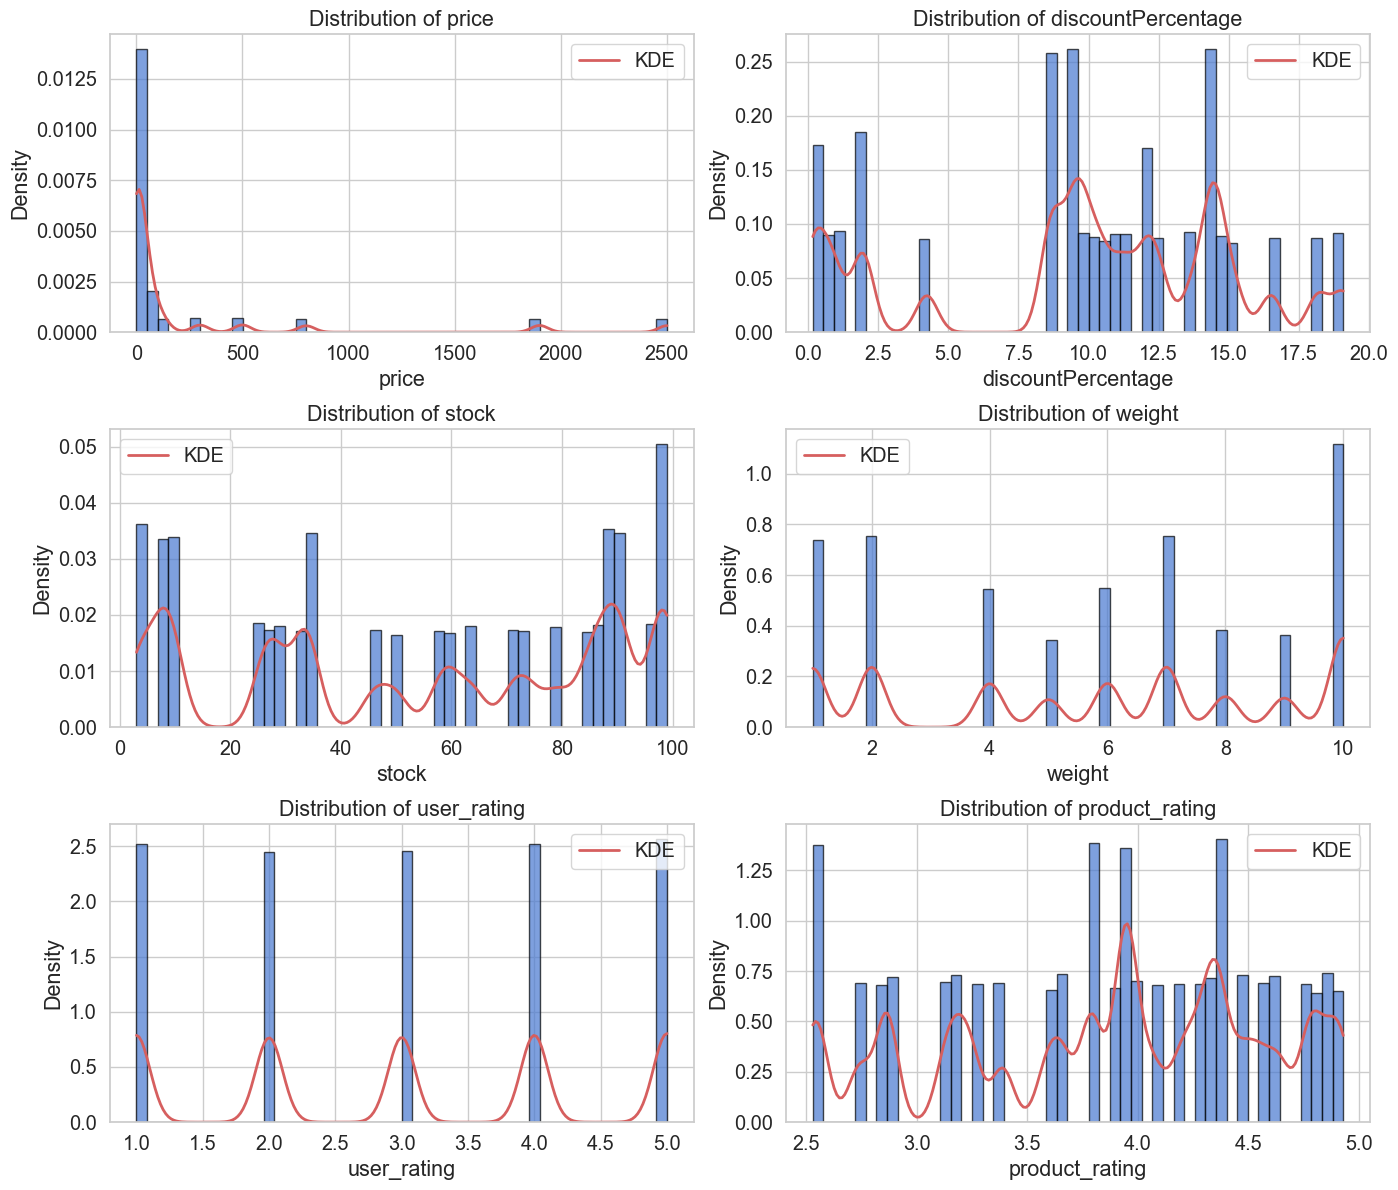

In [7]:
#Distribution plots for numerical columns

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    #Histor plot with KDE
    axes[i].hist(df[col], bins=50, alpha=0.7, edgecolor='black', density=True)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'Distribution of {col}')

    #Add KDE Line
    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(df[col].dropna())
        x_range = np.linspace(df[col].min(), df[col].max(), 200)
        axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
        axes[i].legend()

    except Exception as e:
        pass

plt.tight_layout()
plt.show()        

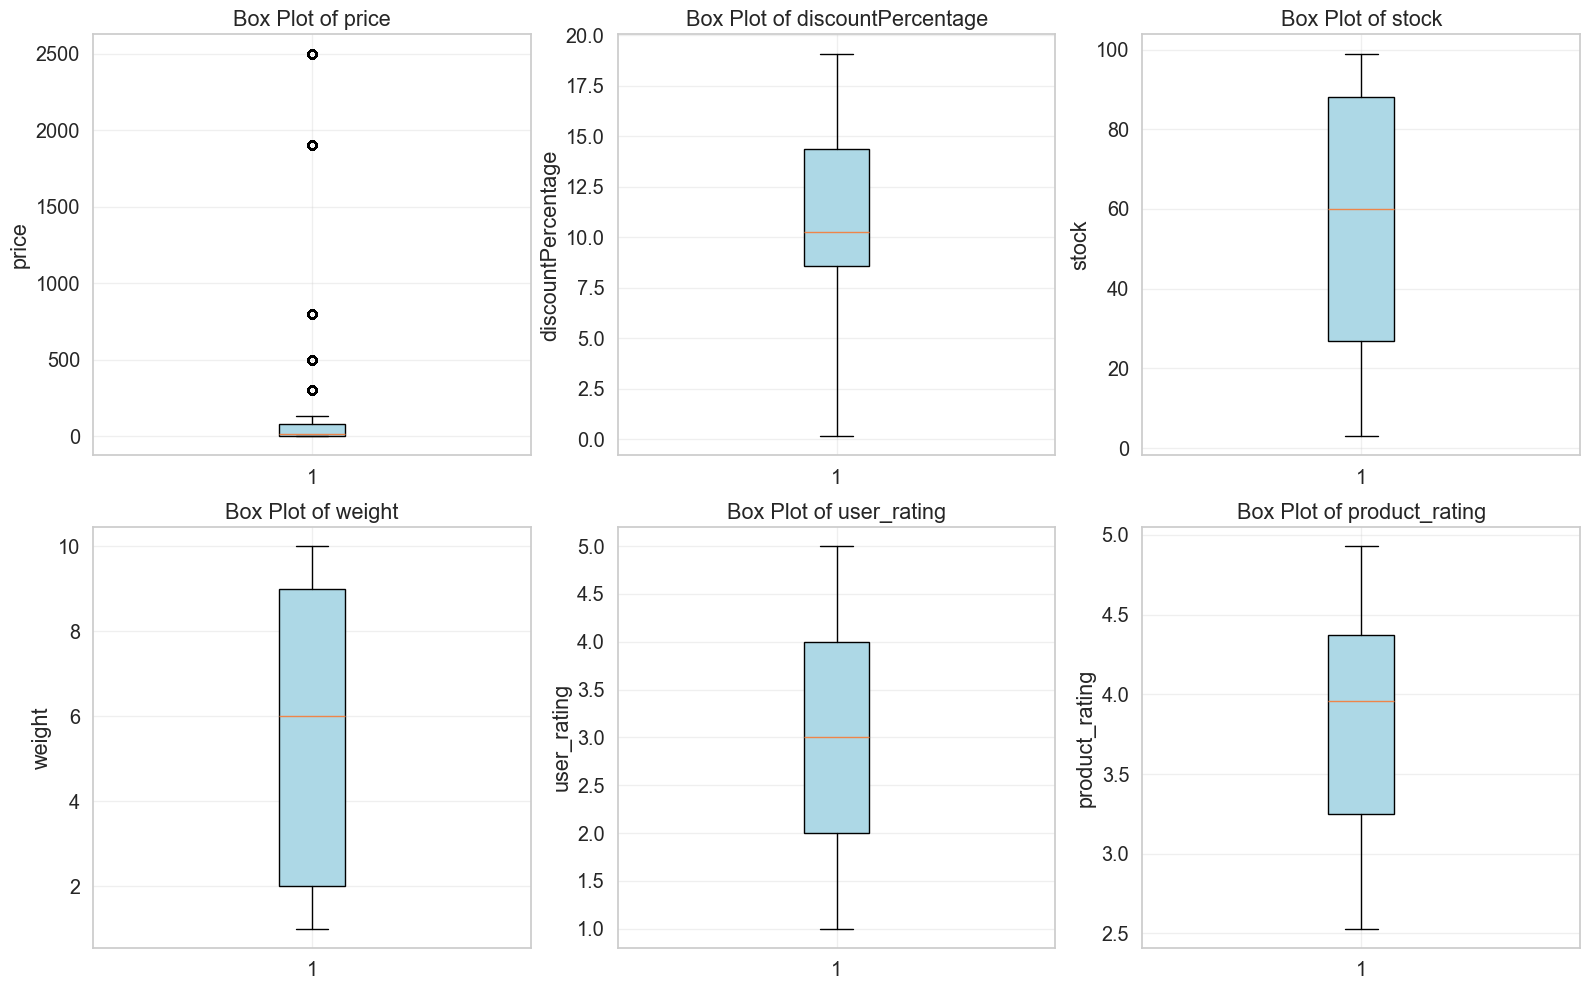

In [8]:
#Box plots for outlier detection

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_ylabel(col)
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Univariate Analysis: Categorical Features

**Purpose:** Understand frequency and distribution of categorical variables

**Analysis Includes:**
- Value counts (frequency distribution)
- Bar charts (visual representation)
- Percentage distribution
- Cardinality (unique values)

**Categorical Features to Analyze:**
- category, interaction_type, brand, availabilityStatus
- price_category, discount_category, product_rating_category, stock_category
- day_period (temporal categorical)

**Insights:**
- Identify dominant categories
- Understand category distribution
- Detect imbalanced categories

In [9]:
# Select categorical columns
categorical_cols = ['category', 'interaction_type', 'brand', 'availabilityStatus']

print("Univariate Analysis - Categorical Features")


for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Missing: {df[col].isnull().sum()}")
        print(f"\n  Value Counts:")
        value_counts = df[col].value_counts()
        for val, count in value_counts.head(10).items():
            percentage = (count / len(df)) * 100
            print(f"    {val}: {count:,} ({percentage:.2f}%)")
        if len(value_counts) > 10:
            print(f"    ... and {len(value_counts) - 10} more categories")


Univariate Analysis - Categorical Features

CATEGORY:
  Unique values: 4
  Missing: 0

  Value Counts:
    groceries: 261,555 (49.82%)
    fragrances: 88,340 (16.83%)
    beauty: 87,640 (16.69%)
    furniture: 87,465 (16.66%)

INTERACTION_TYPE:
  Unique values: 3
  Missing: 0

  Value Counts:
    view: 175,910 (33.51%)
    click: 175,595 (33.45%)
    purchase: 173,495 (33.05%)

BRAND:
  Unique values: 15
  Missing: 0

  Value Counts:
    unknown: 261,555 (49.82%)
    annibale colombo: 34,125 (6.50%)
    knoll: 18,655 (3.55%)
    velvet touch: 18,235 (3.47%)
    furniture co.: 18,200 (3.47%)
    calvin klein: 18,095 (3.45%)
    nail couture: 18,025 (3.43%)
    dolce & gabbana: 17,850 (3.40%)
    dior: 17,710 (3.37%)
    gucci: 17,430 (3.32%)
    ... and 5 more categories

AVAILABILITYSTATUS:
  Unique values: 2
  Missing: 0

  Value Counts:
    in stock: 472,080 (89.92%)
    unknown: 52,920 (10.08%)


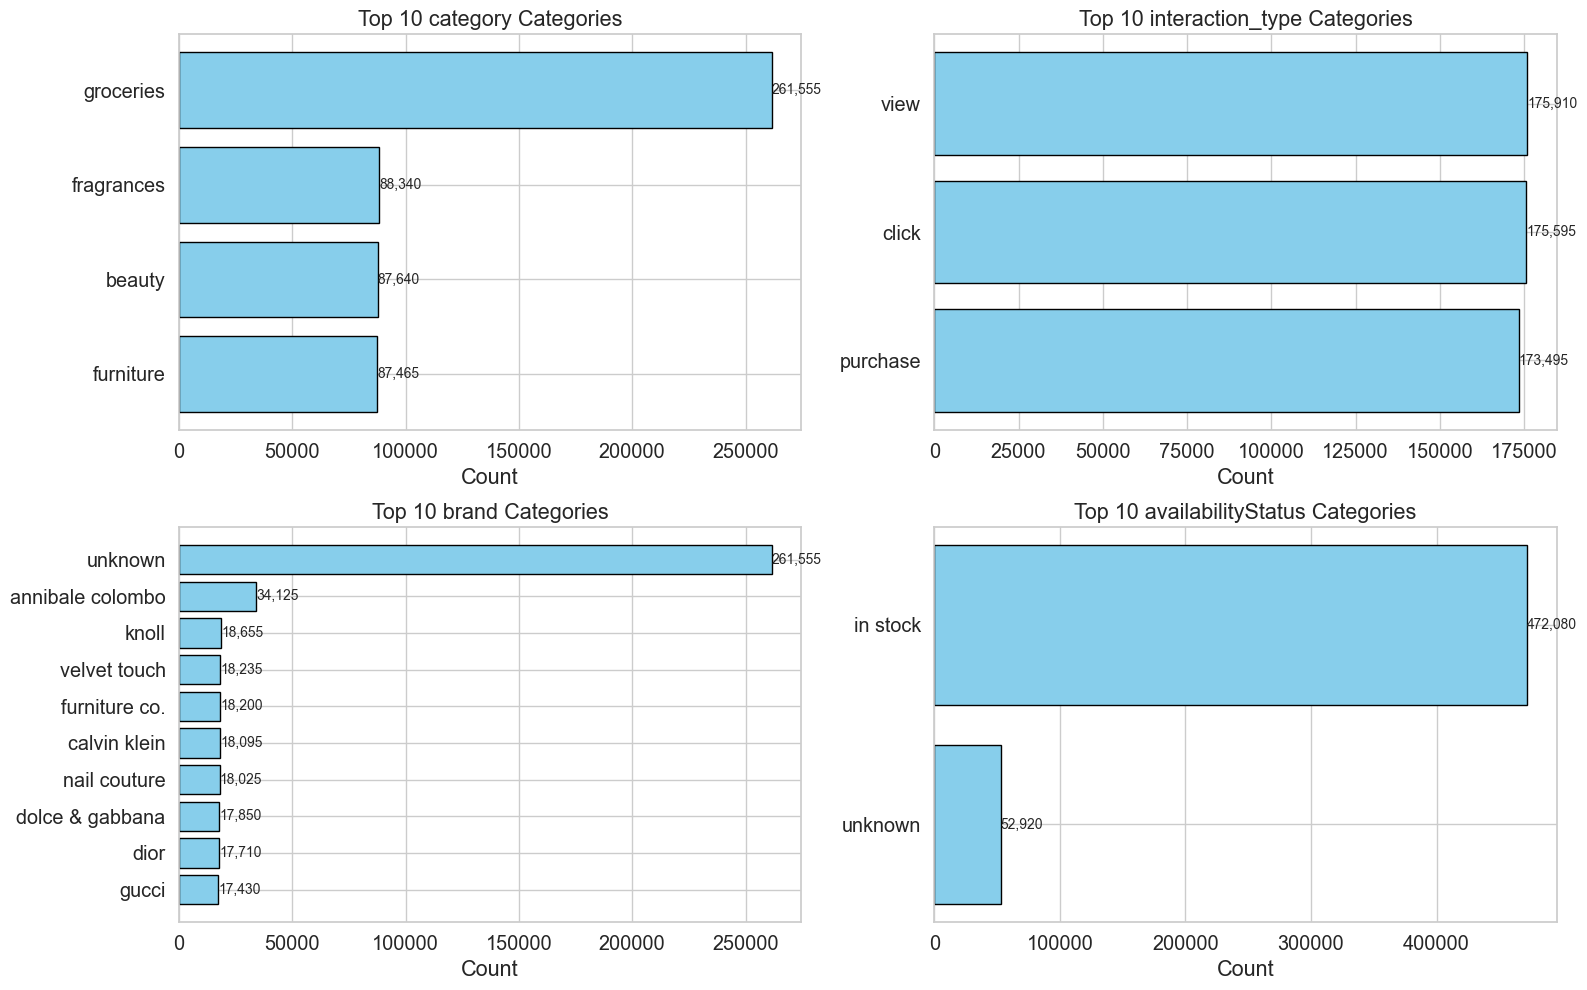

In [10]:
# Visualize top categories
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        value_counts = df[col].value_counts().head(10)
        axes[i].barh(range(len(value_counts)), value_counts.values, color='skyblue', edgecolor='black')
        axes[i].set_yticks(range(len(value_counts)))
        axes[i].set_yticklabels(value_counts.index)
        axes[i].set_xlabel('Count')
        axes[i].set_title(f'Top 10 {col} Categories')
        axes[i].invert_yaxis()

        # add val labels
        for j, val in enumerate(value_counts.values):
            axes[i].text(val, j, f'{val:,}', va='center')

plt.tight_layout()
plt.show()


BINNED CATEGORICAL FEATURES

PRICE_CATEGORY:
price_category
Budget       367290
Luxury        50610
Mid-range     70245
Premium       36855
Name: count, dtype: int64

DISCOUNT_CATEGORY:
discount_category
Low    525000
Name: count, dtype: int64

PRODUCT_RATING_CATEGORY:
product_rating_category
Average       87570
Excellent    227885
Good         209545
Name: count, dtype: int64

STOCK_CATEGORY:
stock_category
High            246120
Low              54215
Medium          120295
Out of Stock    104370
Name: count, dtype: int64


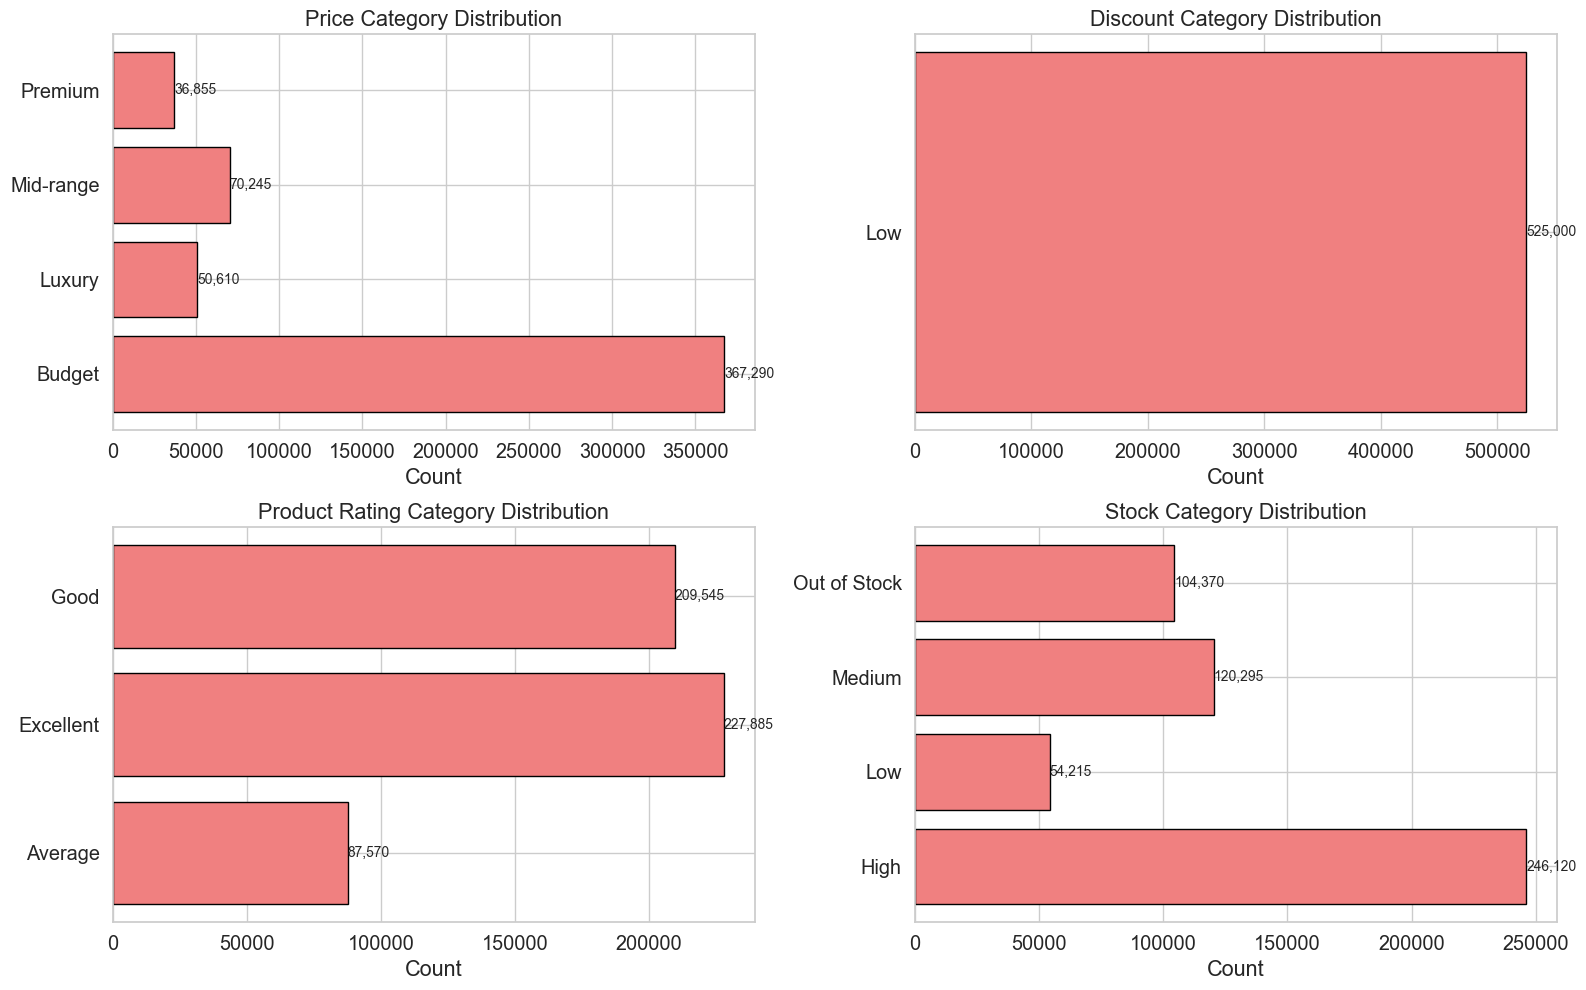

In [11]:
# Binned Categories
binned_cols = ['price_category', 'discount_category', 'product_rating_category', 'stock_category']
print("\n" + "=" * 80)
print("BINNED CATEGORICAL FEATURES")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(binned_cols):
    if col in df.columns:
        value_counts = df[col].value_counts().sort_index()
        print(f"\n{col.upper()}:")
        print(value_counts)

        axes[i].barh(range(len(value_counts)), value_counts.values, color='lightcoral', edgecolor='black')
        axes[i].set_yticks(range(len(value_counts)))
        axes[i].set_yticklabels(value_counts.index)
        axes[i].set_xlabel('Count')
        axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')

        # add val labels
        for j, val in enumerate(value_counts.values):
            axes[i].text(val, j, f'{val:,}', va='center')

plt.tight_layout()
plt.show()

## Bivariate Analysis: Relationships Between Two Variables

**Purpose:** Understand how variables relate to each other

**Analysis Types:**

1. **Numerical vs Numerical:**
   - Scatter plots with regression lines
   - Correlation coefficients (Pearson, Spearman)
   - Joint density plots

2. **Categorical vs Numerical:**
   - Box plots (distribution by category)
   - Violin plots (detailed distribution)
   - Bar plots with error bars (mean ± std)

3. **Categorical vs Categorical:**
   - Crosstabs (contingency tables)
   - Heatmaps (visualization of crosstabs)
   - Grouped bar charts

**Key Questions:**
- Does price correlate with rating?
- Do different categories have different average ratings?
- Is there interaction between discount and purchase behavior?

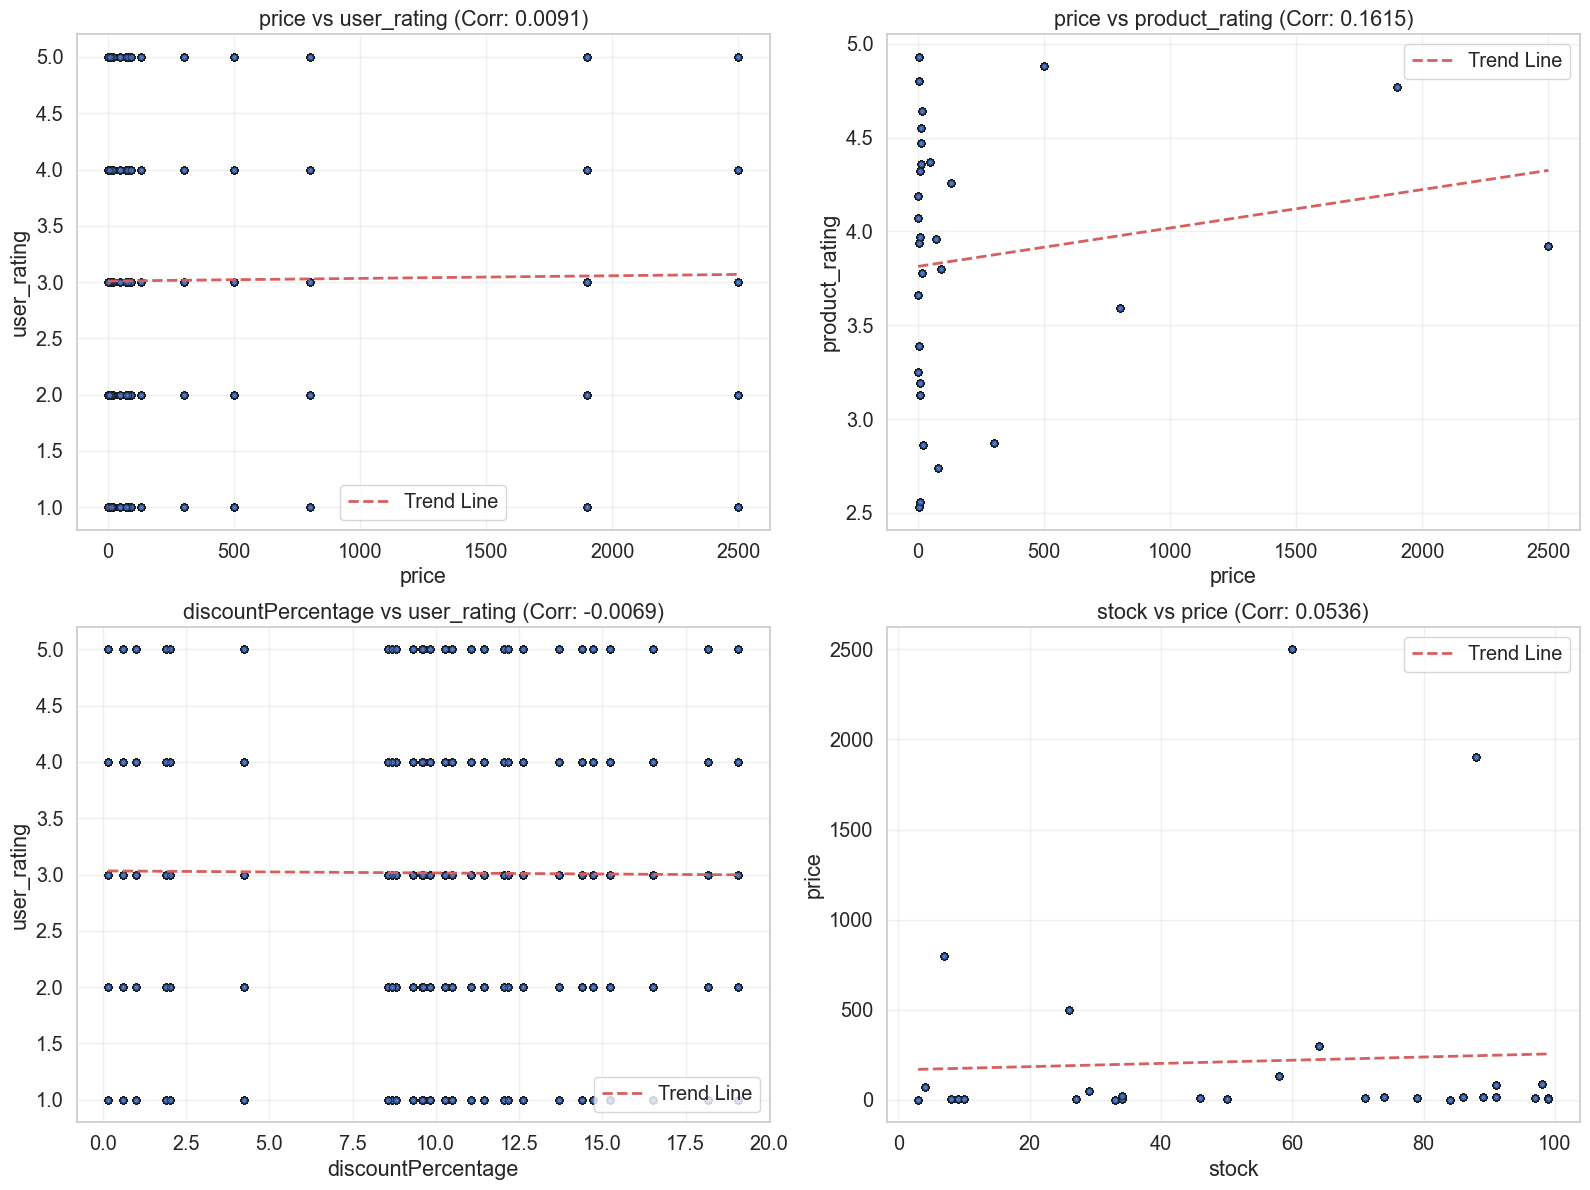

In [12]:
#Selecting numerical pairs for correlation analysis
numerical_pairs = [
    ('price', 'user_rating'),
    ('price', 'product_rating'),
    ('discountPercentage', 'user_rating'),
    ('stock', 'price')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, (col1, col2) in enumerate(numerical_pairs):
    #Scatter plot with regression line
    axes[i].scatter(df[col1], df[col2], alpha=0.5, edgecolor='k', s=20)

    #Add regression line
    z = np.polyfit(df[col1].dropna(), df[col2].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col1].min(), df[col1].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')

    #calculate correlation 
    corr = df[col1].corr(df[col2])

    axes[i].set_xlabel(col1)
    axes[i].set_ylabel(col2)
    axes[i].set_title(f'{col1} vs {col2} (Corr: {corr:.4f})')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

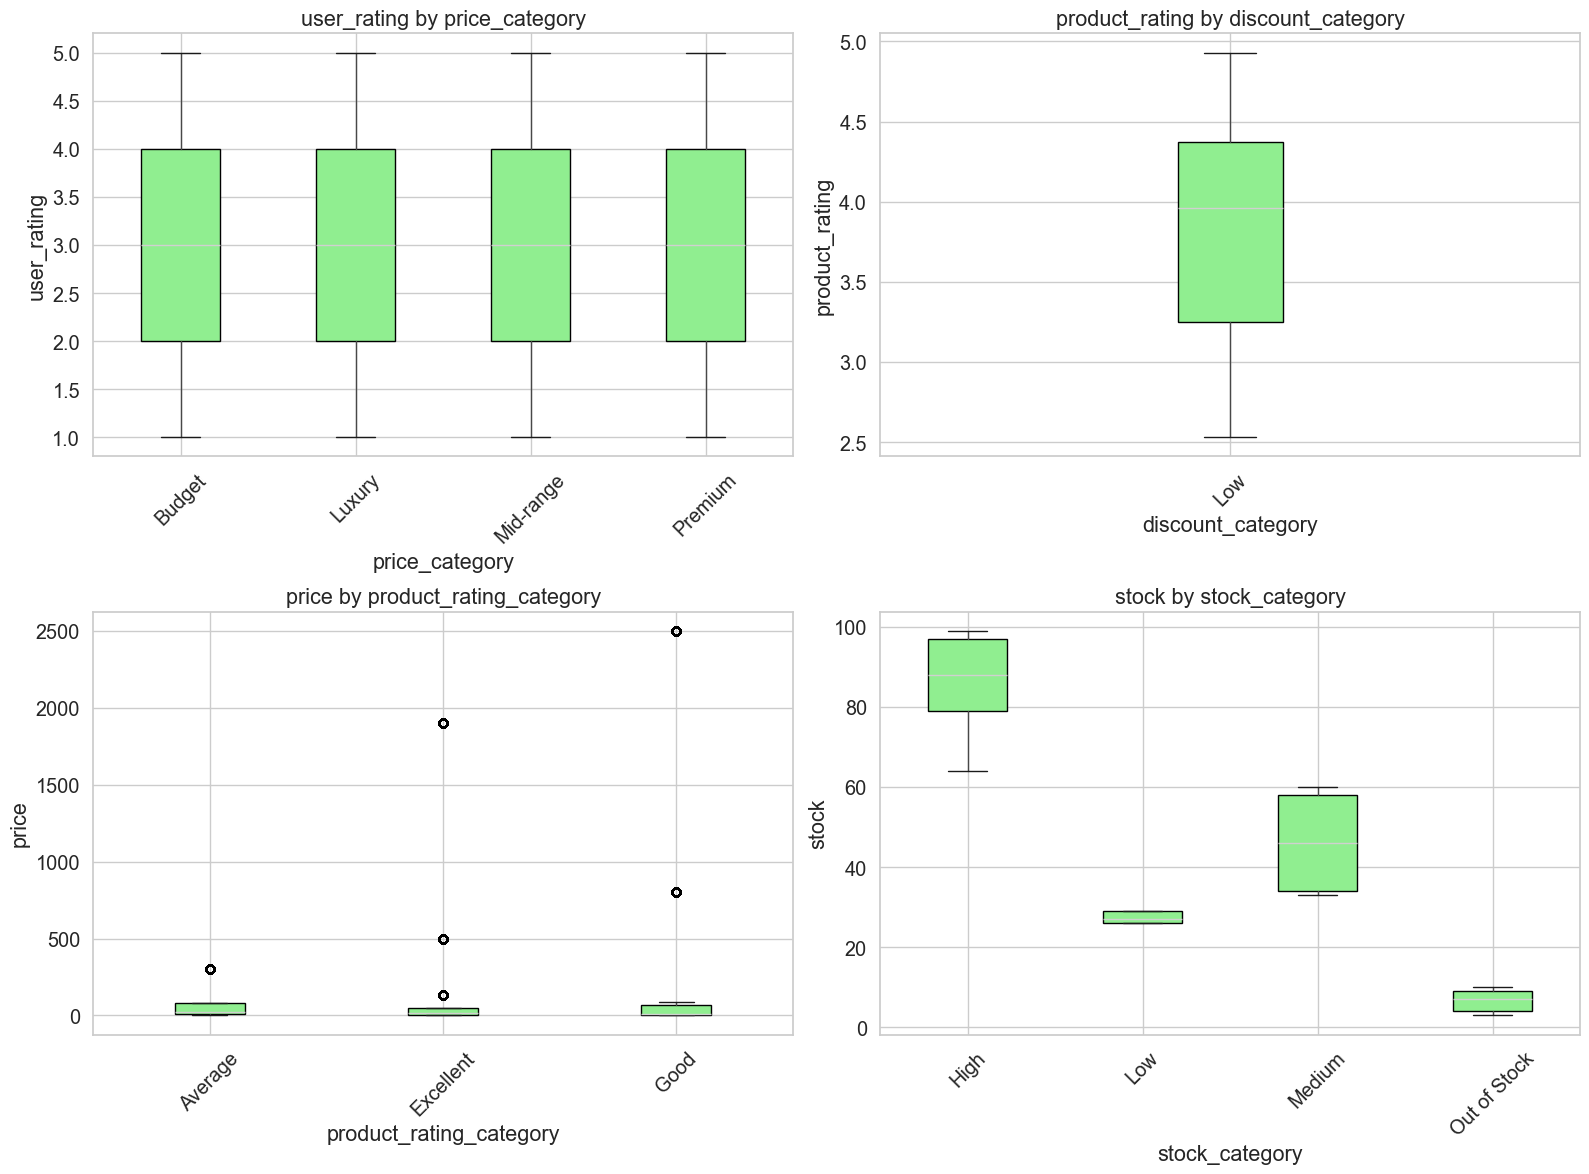

In [13]:
#Numerical vs Categorical Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

categorical_for_analysis = ['price_category', 'discount_category', 'product_rating_category', 'stock_category']
numerical_for_analysis = ['user_rating', 'product_rating', 'price', 'stock']


for i, (cat_col, num_col) in enumerate(zip(categorical_for_analysis, numerical_for_analysis)):
    if cat_col in df.columns:
        #box plot of numerical vs categorical
        df.boxplot(column=num_col, by=cat_col, ax=axes[i], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
        axes[i].set_title(f"{num_col} by {cat_col}")
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        plt.sca(axes[i])
        plt.xticks(rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()


Crosstab of Price Category vs Interaction Type:
interaction_type   click  purchase    view
price_category                            
Budget            123200    119980  124110
Luxury             16100     18340   16170
Mid-range          23275     22750   24220
Premium            13020     12425   11410


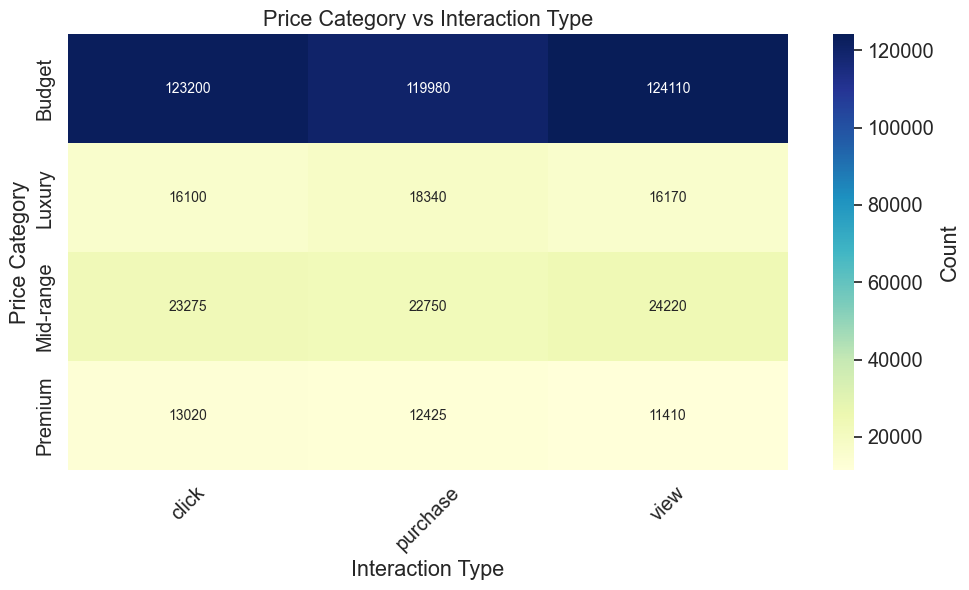

In [14]:
# Categorical vs categorical analysis

if 'price_category' in df.columns and 'interaction_type' in df.columns:
    cross_tab = pd.crosstab(df['price_category'], df['interaction_type'])
    print("\nCrosstab of Price Category vs Interaction Type:")
    print(cross_tab)

    plt.figure(figsize=(10, 6))
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Count'})
    plt.title('Price Category vs Interaction Type')
    plt.xlabel('Interaction Type')
    plt.ylabel('Price Category')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Correlation Analysis

**Purpose:** Identify linear relationships between numerical variables

**Methods:**
1. **Pearson Correlation:** Measures linear relationship (-1 to 1)
   - +1: Perfect positive correlation
   - 0: No correlation
   - -1: Perfect negative correlation

2. **Spearman Correlation:** Measures monotonic relationship (rank-based)
   - Robust to outliers
   - Better for non-linear relationships

3. **Correlation Matrix:** Shows all pairwise correlations

**Interpretation:**
- |r| > 0.7: Strong correlation
- 0.3 < |r| < 0.7: Moderate correlation
- |r| < 0.3: Weak correlation

**Heatmap Visualization:**
- Red: Positive correlation
- Blue: Negative correlation
- Lighter colors: Weaker correlation

In [15]:
# Correlation Matrix Calculation

numerical_col_for_corr = ['price', 'discountPercentage', 'stock', 'weight', 'user_rating', 'product_rating']

#ensure all columns exists

numerical_col_for_corr = [col for col in numerical_col_for_corr if col in df.columns]

correlation_matrix = df[numerical_col_for_corr].corr()
print("\nPearson Correlation Matrix:")
print(correlation_matrix)


Pearson Correlation Matrix:
                       price  discountPercentage     stock    weight  \
price               1.000000            0.084270  0.053638  0.240466   
discountPercentage  0.084270            1.000000  0.352232 -0.136289   
stock               0.053638            0.352232  1.000000 -0.088911   
weight              0.240466           -0.136289 -0.088911  1.000000   
user_rating         0.009149           -0.006905 -0.001691  0.008598   
product_rating      0.161499           -0.215051  0.090066  0.363355   

                    user_rating  product_rating  
price                  0.009149        0.161499  
discountPercentage    -0.006905       -0.215051  
stock                 -0.001691        0.090066  
weight                 0.008598        0.363355  
user_rating            1.000000        0.002516  
product_rating         0.002516        1.000000  



Strong Correlations (|corr| > 0.5):


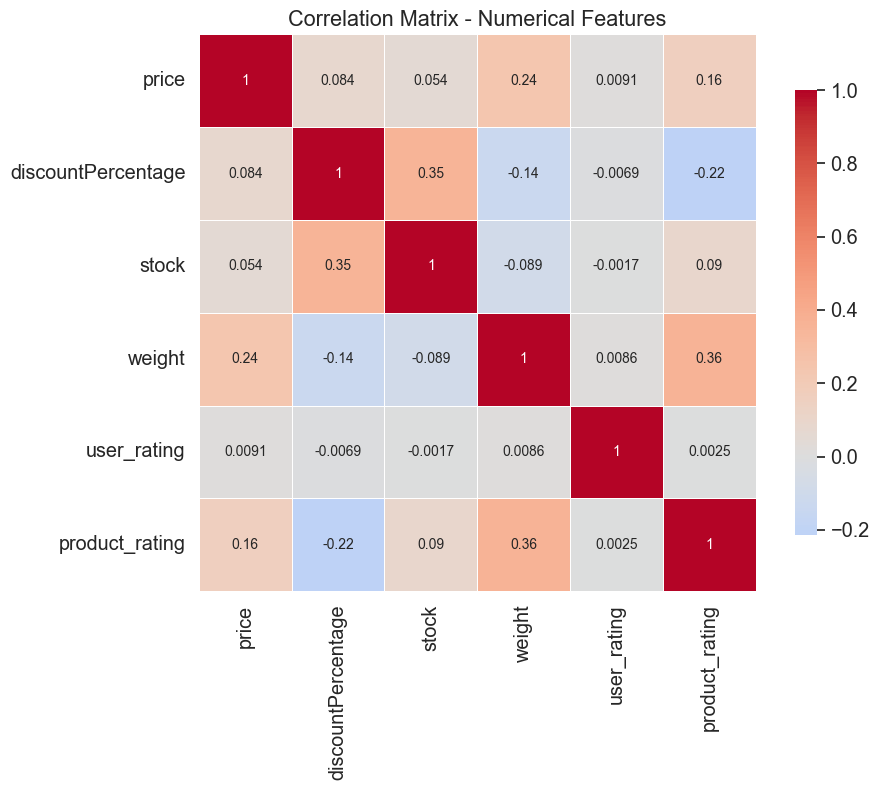

In [16]:
# Finding Strong Correlations
print("\nStrong Correlations (|corr| > 0.5):")
for i in range(len(correlation_matrix.columns)):
    for j  in range(i +1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"  {col1} and {col2}: {corr_value:.4f}")

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()

In [17]:
#spearsman correlation for non-parametric data
spearsman_corr = df[numerical_col_for_corr].corr(method='spearman')
print("\nSpearman Correlation Matrix:")
print(spearsman_corr)


Spearman Correlation Matrix:
                       price  discountPercentage     stock    weight  \
price               1.000000            0.215652  0.163100  0.358590   
discountPercentage  0.215652            1.000000  0.401057 -0.186359   
stock               0.163100            0.401057  1.000000 -0.153342   
weight              0.358590           -0.186359 -0.153342  1.000000   
user_rating         0.010974           -0.009002 -0.002432  0.008331   
product_rating      0.081141           -0.174799  0.087166  0.349929   

                    user_rating  product_rating  
price                  0.010974        0.081141  
discountPercentage    -0.009002       -0.174799  
stock                 -0.002432        0.087166  
weight                 0.008331        0.349929  
user_rating            1.000000        0.003428  
product_rating         0.003428        1.000000  


## Distribution Analysis

**Purpose:** Understand how data is distributed across ranges

**Visualizations:**
1. **Histograms:** Raw frequency distribution
2. **KDE (Kernel Density Estimation):** Smooth probability density
3. **CDF (Cumulative Distribution):** Cumulative probability
4. **Q-Q Plots:** Compare against normal distribution

**Questions Answered:**
- Is the data normally distributed?
- Are there multiple peaks (bimodal, multimodal)?
- Where do most values concentrate?
- How do extremes compare?

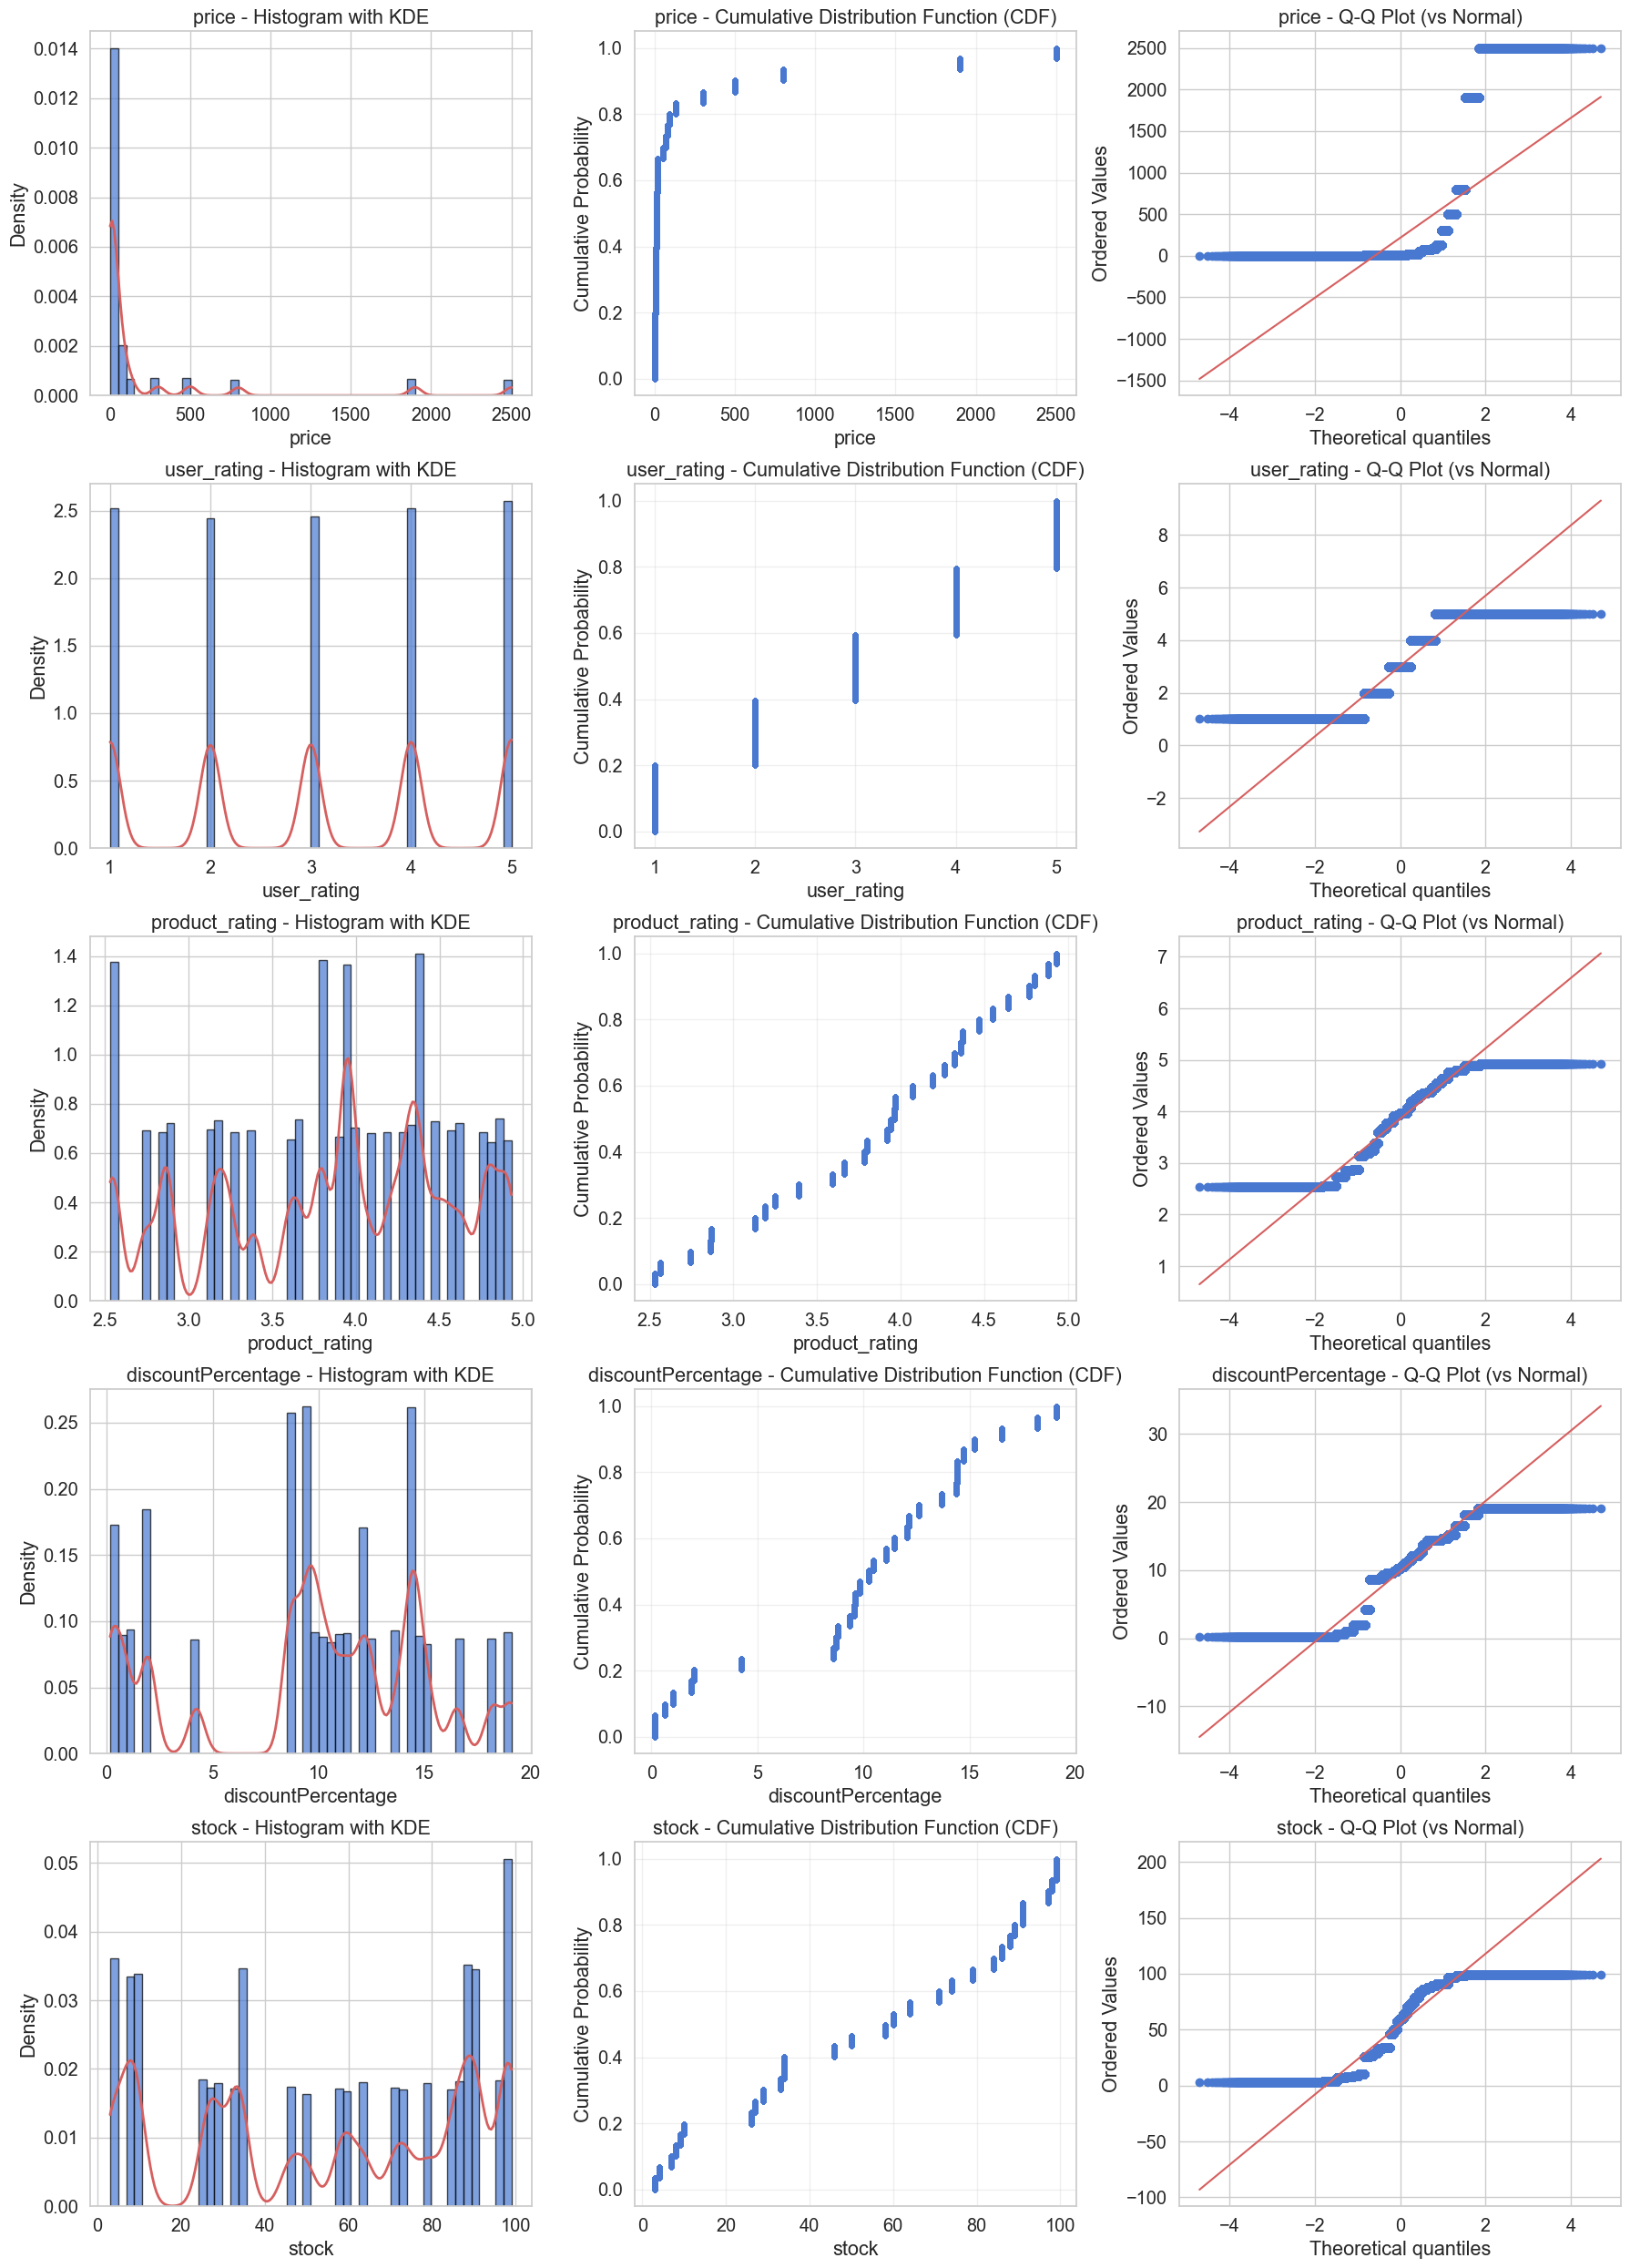

In [18]:
# Detailed Distribution Plots for Numerical Features
numerical_cols = ['price', 'user_rating', 'product_rating', 'discountPercentage', 'stock']
numerical_cols = [col for col in numerical_cols if col in df.columns]

fig, axes = plt.subplots(len(numerical_cols), 3, figsize=(18, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Histogram with KDE
    axes[i, 0].hist(df[col], bins=50, alpha=0.7, edgecolor='black', density=True)

    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(df[col].dropna())
        x_range = np.linspace(df[col].min(), df[col].max(), 200)
        axes[i, 0].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    except:
        pass

    axes[i, 0].set_title(f'{col} - Histogram with KDE')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Density')

    # CDF
    sorted_data = np.sort(df[col].dropna())
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    axes[i, 1].plot(sorted_data, cdf, marker='.', linestyle='none', linewidth=2)
    axes[i, 1].set_title(f'{col} - Cumulative Distribution Function (CDF)')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Cumulative Probability')
    axes[i, 1].grid(True, alpha=0.3)


    #Q-q Plot (Compare with normal distribution)
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i, 2])
    axes[i, 2].set_title(f'{col} - Q-Q Plot (vs Normal)')

plt.tight_layout()
plt.show()

## Temporal Analysis

**Purpose:** Understand patterns over time

**Temporal Features:**
- hour: Hour of day (0-23)
- day_of_week: Day of week (0-6)
- day_period: Time period (morning, afternoon, evening, night)
- is_weekend: Binary flag

**Analysis:**
- Hourly trends: When is activity peak?
- Daily patterns: Day-to-day variations
- Weekend vs Weekday: Behavior differences
- Time period preferences: When do users interact most?

**Use Case:** Optimize resource allocation, target marketing campaigns, understand user behavior patterns

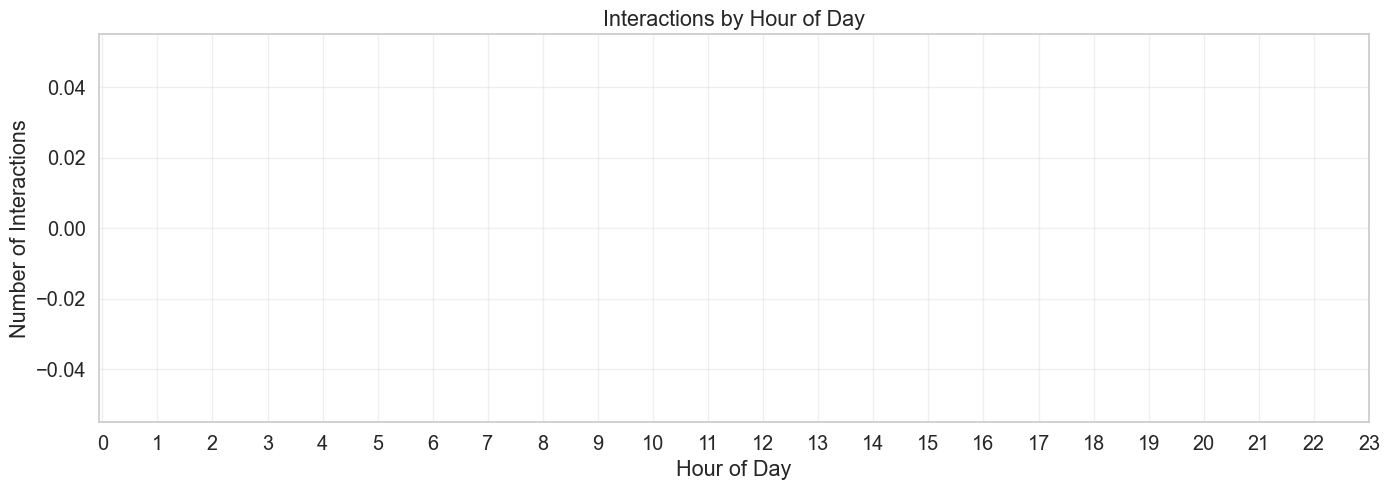


Hourly Distribution:
Series([], Name: count, dtype: int64)


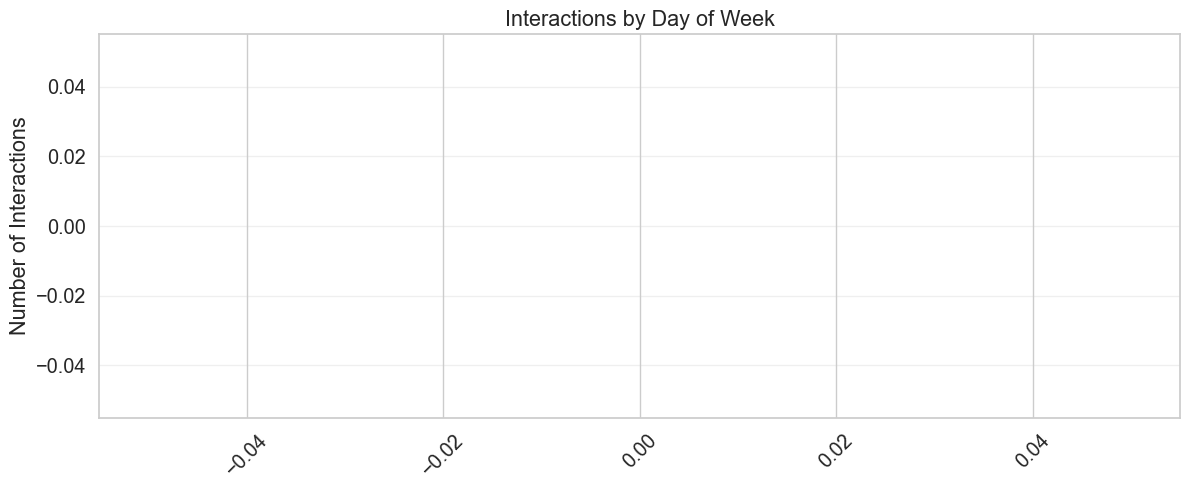


Daily Distribution:
Series([], Name: count, dtype: int64)


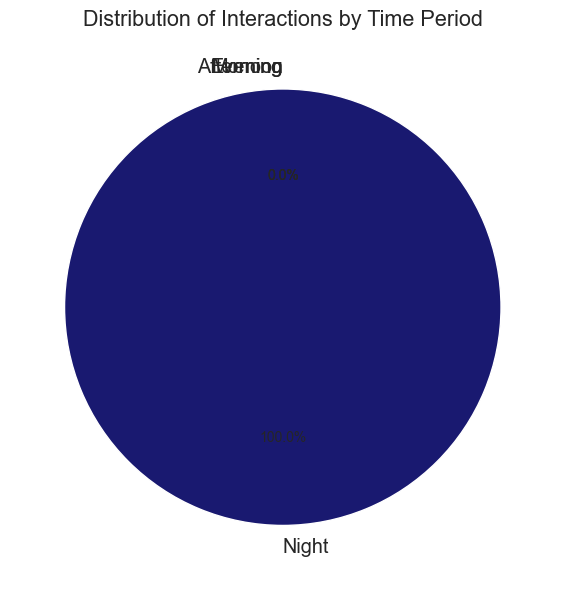


Time Period Distribution:
day_period
Morning           0
Afternoon         0
Evening           0
Night        525000
Name: count, dtype: int64


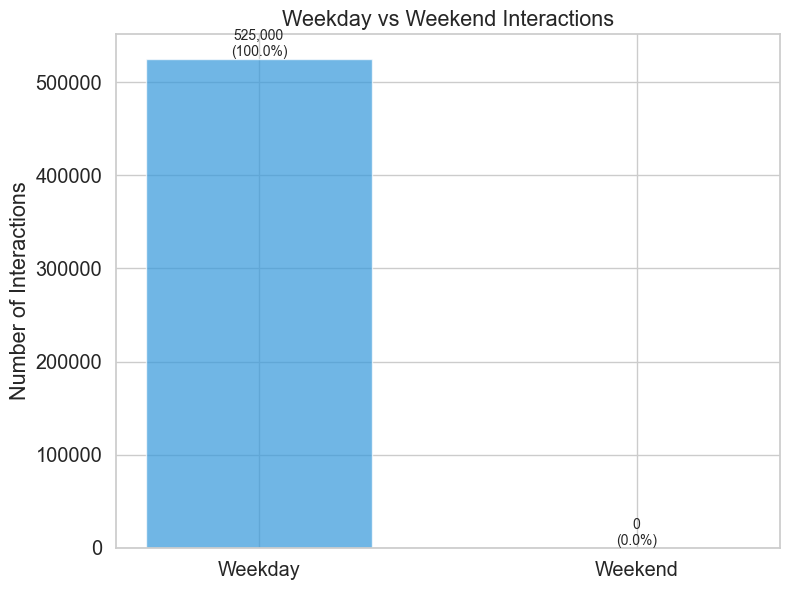

In [19]:
# Check if temporal columns exist
temporal_cols = ['hour', 'day_of_week', 'day_period', 'is_weekend']
temporal_cols = [col for col in temporal_cols if col in df.columns]

if len(temporal_cols) > 0:
    # Hourly analysis
    if 'hour' in df.columns:
        hourly_counts = df['hour'].value_counts().sort_index()
        plt.figure(figsize=(14, 5))
        plt.plot(hourly_counts.index, hourly_counts.values, marker='o', linewidth=2, markersize=6)
        plt.xlabel('Hour of Day')
        plt.ylabel('Number of Interactions')
        plt.title('Interactions by Hour of Day')
        plt.grid(True, alpha=0.3)
        plt.xticks(range(0, 24))
        plt.tight_layout()
        plt.show()
        
        print("\nHourly Distribution:")
        print(hourly_counts)
    
    # Day of week analysis
    if 'day_of_week' in df.columns:
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        daily_counts = df['day_of_week'].value_counts().sort_index()
        
        plt.figure(figsize=(12, 5))
        plt.bar(range(len(daily_counts)), daily_counts.values, color='steelblue', alpha=0.7)
        # Only set xticks if there's data
        if len(daily_counts) > 0:
            plt.xticks(range(len(daily_counts)), [day_names[i] for i in daily_counts.index], rotation=45)
        else:
            plt.xticks(rotation=45)
        plt.ylabel('Number of Interactions')
        plt.title('Interactions by Day of Week')
        plt.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for i, v in enumerate(daily_counts.values):
            plt.text(i, v, f'{v:,}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print("\nDaily Distribution:")
        print(daily_counts)
    
    # Day period analysis
    if 'day_period' in df.columns:
        period_counts = df['day_period'].value_counts()
        period_order = ['Morning', 'Afternoon', 'Evening', 'Night']
        period_counts = period_counts.reindex(period_order, fill_value=0)
        
        plt.figure(figsize=(10, 6))
        colors = ['#FFD700', '#FF8C00', '#4169E1', '#191970']
        plt.pie(period_counts.values, labels=period_counts.index, autopct='%1.1f%%', 
                colors=colors, startangle=90)
        plt.title('Distribution of Interactions by Time Period')
        plt.tight_layout()
        plt.show()
        
        print("\nTime Period Distribution:")
        print(period_counts)
    
    # Weekend vs Weekday
    if 'is_weekend' in df.columns:
        weekend_counts = df['is_weekend'].value_counts()
        labels = ['Weekday', 'Weekend']
        values = [weekend_counts.get(0, 0), weekend_counts.get(1, 0)]
        
        plt.figure(figsize=(8, 6))
        bars = plt.bar(labels, values, color=['#3498db', '#e74c3c'], alpha=0.7, width=0.6)
        plt.ylabel('Number of Interactions')
        plt.title('Weekday vs Weekend Interactions')
        
        # Add value labels
        for bar, value in zip(bars, values):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:,}\n({value/sum(values)*100:.1f}%)',
                    ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()

## Interaction Type Analysis

**Purpose:** Understand different types of user interactions

**Interaction Types:**
- view: User viewed the product
- cart: User added to cart
- purchase: User completed purchase
- add/remove: Added/removed from wishlist
- other interactions

**Analysis:**
- Frequency of each interaction type
- Conversion funnel (view → cart → purchase)
- Average rating by interaction type
- Price correlation with interaction type

**Business Insight:**
- Understand user behavior journey
- Identify drop-off points in funnel
- Optimize for higher conversions


Interaction Type Distribution:
interaction_type
view        175910
click       175595
purchase    173495
Name: count, dtype: int64


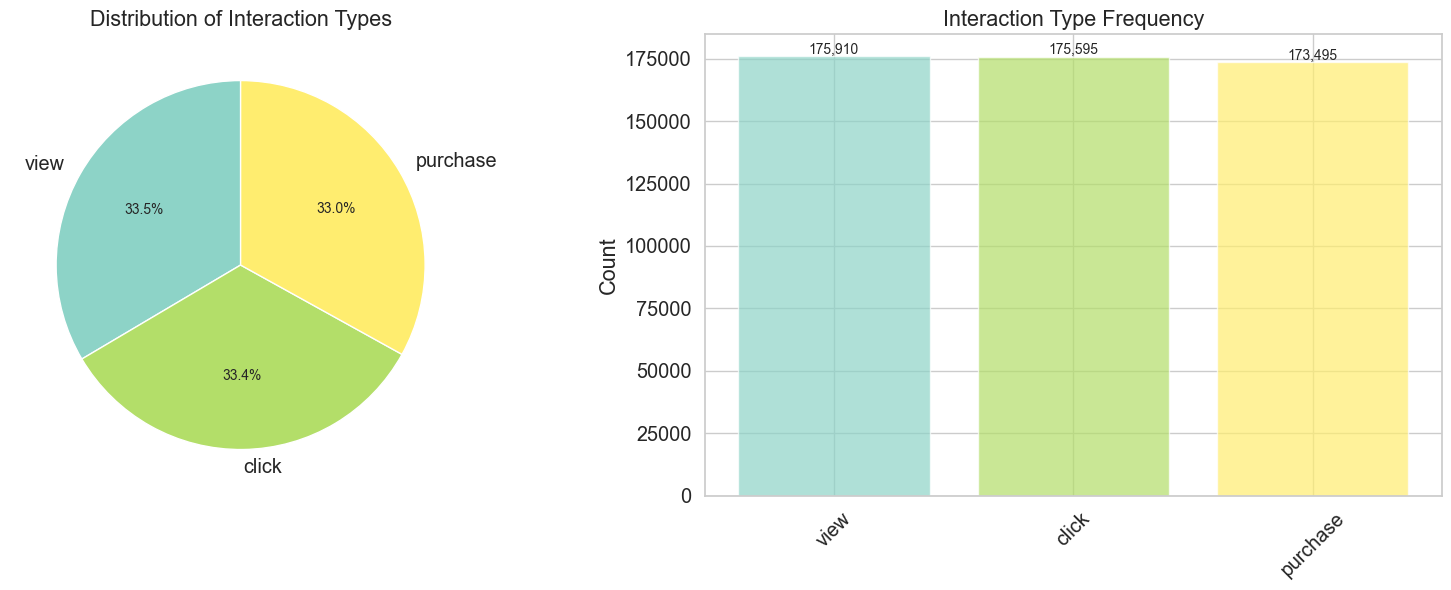


Average Rating by Interaction Type:
                      mean   count       std
interaction_type                            
click             2.984054  175595  1.427036
purchase          3.012709  173495  1.412947
view              3.045762  175910  1.426787


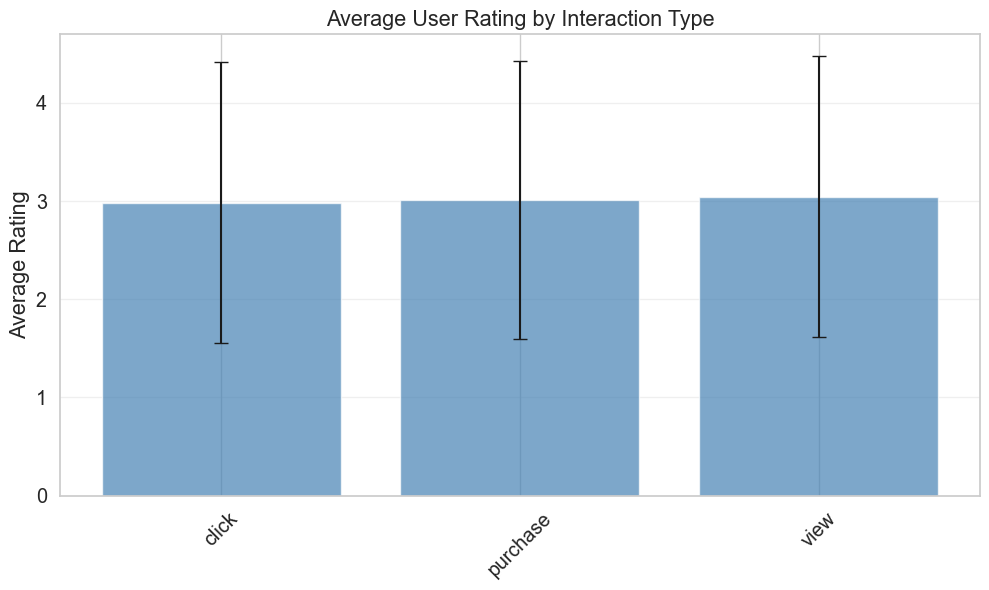

In [20]:
if 'interaction_type' in df.columns:
    # Interaction type distribution
    interaction_counts = df['interaction_type'].value_counts()
    
    print("\nInteraction Type Distribution:")
    print(interaction_counts)
    
    # Pie chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pie chart
    colors = plt.cm.Set3(np.linspace(0, 1, len(interaction_counts)))
    ax1.pie(interaction_counts.values, labels=interaction_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax1.set_title('Distribution of Interaction Types')
    
    # Bar chart
    ax2.bar(range(len(interaction_counts)), interaction_counts.values, color=colors, alpha=0.7)
    ax2.set_xticks(range(len(interaction_counts)))
    ax2.set_xticklabels(interaction_counts.index, rotation=45)
    ax2.set_ylabel('Count')
    ax2.set_title('Interaction Type Frequency')
    
    # Add value labels
    for i, v in enumerate(interaction_counts.values):
        ax2.text(i, v, f'{v:,}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Average rating by interaction type
    if 'user_rating' in df.columns:
        rating_by_interaction = df.groupby('interaction_type')['user_rating'].agg(['mean', 'count', 'std'])
        print("\nAverage Rating by Interaction Type:")
        print(rating_by_interaction)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        x_pos = np.arange(len(rating_by_interaction))
        ax.bar(x_pos, rating_by_interaction['mean'], 
               yerr=rating_by_interaction['std'], capsize=5, 
               alpha=0.7, color='steelblue')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(rating_by_interaction.index, rotation=45)
        ax.set_ylabel('Average Rating')
        ax.set_title('Average User Rating by Interaction Type')
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

## User and Product Analysis

**Purpose:** Understand user behavior and product performance

**User Analysis:**
- Most active users
- Average rating per user
- Purchase frequency
- User segments by activity level

**Product Analysis:**
- Top-rated products
- Best-selling products
- Most viewed products
- Product diversity (categories)

**Insights:**
- Identify power users
- Recognize high-value products
- Understand product preferences
- Segment users for targeting


Top 10 Most Active Users:
         interaction_count  avg_rating   avg_price
user_id                                           
6975                   315    3.888889   18.601111
652                    280    2.875000  105.740000
2298                   280    3.375000  259.490000
9374                   280    3.500000  624.615000
359                    245    2.714286  319.175714
519                    245    3.142857   25.204286
1803                   245    3.714286   18.775714
4548                   245    3.714286   35.490000
5169                   245    3.285714   88.204286
6265                   245    2.571429   94.775714


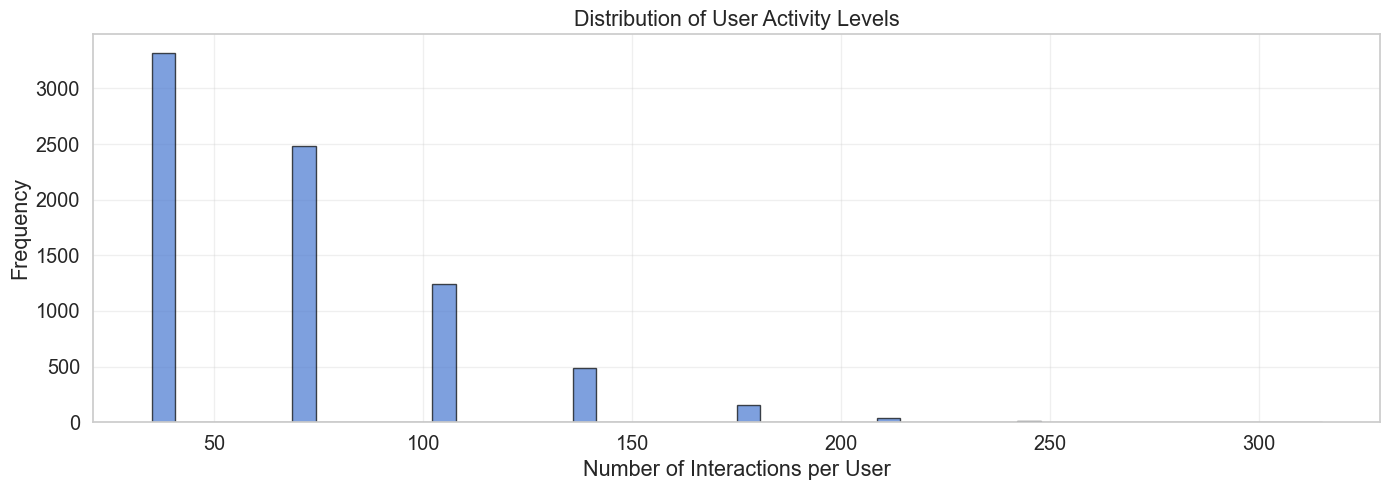

In [21]:
# User Analysis
if 'user_id' in df.columns:
    user_stats = df.groupby('user_id').agg({
        'user_id': 'count',
        'user_rating': ['mean', 'std'],
        'price': 'mean'
    }).rename(columns={'user_id': 'interaction_count'})
    
    user_stats.columns = ['interaction_count', 'avg_rating', 'rating_std', 'avg_price']
    
    print("\nTop 10 Most Active Users:")
    print(user_stats.nlargest(10, 'interaction_count')[['interaction_count', 'avg_rating', 'avg_price']])
    
    # User activity distribution
    plt.figure(figsize=(14, 5))
    plt.hist(user_stats['interaction_count'], bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Number of Interactions per User')
    plt.ylabel('Frequency')
    plt.title('Distribution of User Activity Levels')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



Top 10 Most Interacted Products:
            interaction_count  avg_user_rating  avg_product_rating   price
product_id                                                                
14                      18655         3.035647                4.88  499.99
26                      18585         3.032015                3.66    0.99
19                      18445         3.085389                3.19    9.99
17                      18375         3.019048                4.47   12.99
3                       18235         3.009597                4.64   14.99
13                      18200         3.015385                2.87  299.99
6                       18095         3.102515                4.37   49.99
5                       18025         3.050485                4.32    8.99
23                      17955         2.955166                2.53    2.99
9                       17850         2.998039                3.96   69.99

Top 10 Highest Rated Products:
            interaction_count  avg

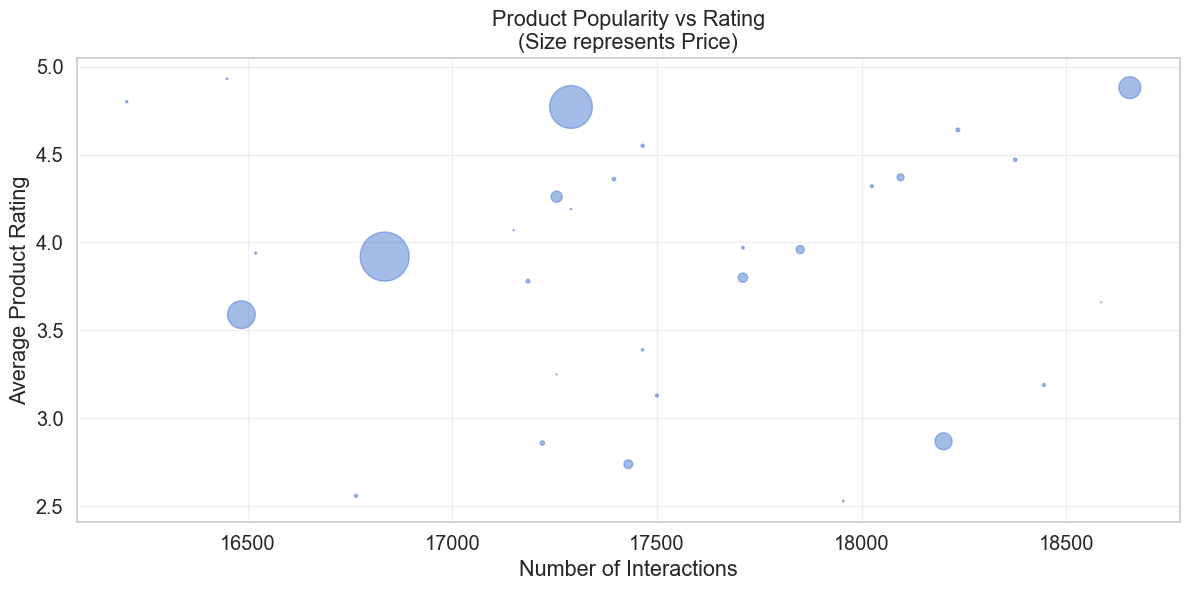

In [22]:
# Product Analysis
if 'product_id' in df.columns:
    product_stats = df.groupby('product_id').agg({
        'product_id': 'count',
        'user_rating': 'mean',
        'product_rating': 'mean',
        'price': 'first'
    }).rename(columns={'product_id': 'interaction_count'})
    
    product_stats.columns = ['interaction_count', 'avg_user_rating', 'avg_product_rating', 'price']
    
    print("\nTop 10 Most Interacted Products:")
    print(product_stats.nlargest(10, 'interaction_count'))
    
    print("\nTop 10 Highest Rated Products:")
    print(product_stats.nlargest(10, 'avg_product_rating'))
    
    # Product rating vs interaction count scatter
    plt.figure(figsize=(12, 6))
    plt.scatter(product_stats['interaction_count'], product_stats['avg_product_rating'], 
               s=product_stats['price']/2, alpha=0.5)
    plt.xlabel('Number of Interactions')
    plt.ylabel('Average Product Rating')
    plt.title('Product Popularity vs Rating\n(Size represents Price)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



Top 15 Categories by Interaction Count:
             count  user_rating        price
category                                    
groceries   261555     2.993845     6.084928
fragrances   88340     3.010301    83.595388
beauty       87640     3.045128    13.384968
furniture    87465     3.048019  1176.620652


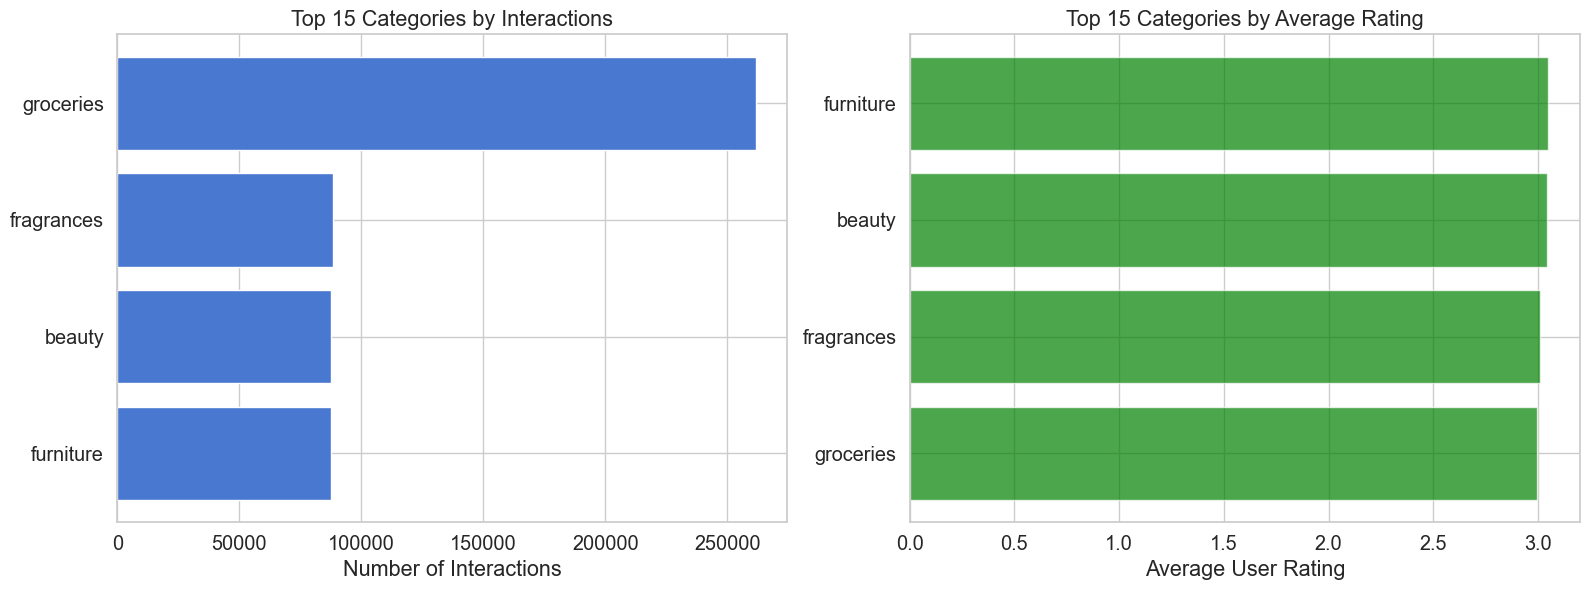

In [23]:
# Category Analysis
if 'category' in df.columns:
    category_stats = df.groupby('category').agg({
        'product_id': 'count',
        'user_rating': 'mean',
        'price': 'mean'
    }).rename(columns={'product_id': 'count'})
    
    category_stats = category_stats.sort_values('count', ascending=False)
    
    print("\nTop 15 Categories by Interaction Count:")
    print(category_stats.head(15))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top categories
    top_categories = category_stats.head(15)
    axes[0].barh(range(len(top_categories)), top_categories['count'].values)
    axes[0].set_yticks(range(len(top_categories)))
    axes[0].set_yticklabels(top_categories.index)
    axes[0].set_xlabel('Number of Interactions')
    axes[0].set_title('Top 15 Categories by Interactions')
    axes[0].invert_yaxis()
    
    # Average rating by category
    top_rated = category_stats.nlargest(15, 'user_rating')
    axes[1].barh(range(len(top_rated)), top_rated['user_rating'].values, color='green', alpha=0.7)
    axes[1].set_yticks(range(len(top_rated)))
    axes[1].set_yticklabels(top_rated.index)
    axes[1].set_xlabel('Average User Rating')
    axes[1].set_title('Top 15 Categories by Average Rating')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

## Key Insights Summary

**Major Findings:**
1. **Data Quality:** Identified data quality metrics and distributions
2. **User Behavior:** Patterns in when and how users interact
3. **Product Performance:** Top products and categories
4. **Relationships:** Correlations between features
5. **Anomalies:** Outliers and unusual patterns

**Actionable Recommendations:**
- Target high-activity time periods for campaigns
- Focus on top-performing categories and products
- Improve underperforming products
- Segment users based on behavior patterns
- Optimize pricing strategy based on demand

**Next Steps:**
- Feature engineering for modeling
- Build predictive models
- Implement recommendations

In [24]:
summary_stats = {
    'Total Records': len(df),
    'Total Features': len(df.columns),
    'Memory Usage (MB)': df.memory_usage(deep=True).sum() / (1024**2),
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Records': df.duplicated().sum(),
}

In [25]:
print("\nDataset Overview:")
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value:,}")


Dataset Overview:
  Total Records: 525,000
  Total Features: 54
  Memory Usage (MB): 1339.76
  Missing Values: 3,150,000
  Duplicate Records: 510,022


In [26]:
print("\nNumerical Features Summary:")
numerical_summary = df.select_dtypes(include=[np.number]).describe().loc[['mean', 'std', 'min', 'max']]
print(numerical_summary)


Numerical Features Summary:
           user_id  product_id  user_rating  timestamp        id        price  \
mean   4923.265867    15.45060     3.014200        NaN  15.45060   215.357227   
std    2891.419679     8.62296     1.422534        NaN   8.62296   553.513839   
min       1.000000     1.00000     1.000000        NaN   1.00000     0.990000   
max   10000.000000    30.00000     5.000000        NaN  30.00000  2499.990000   

      discountPercentage  product_rating      stock     weight  ...  \
mean            9.801174        3.857455  54.919333   5.811400  ...   
std             5.392197        0.702336  33.257432   3.184292  ...   
min             0.160000        2.530000   3.000000   1.000000  ...   
max            19.090000        4.930000  99.000000  10.000000  ...   

      price_normalized  discount_normalized  stock_normalized  \
mean          0.085781             0.509307          0.540826   
std           0.221494             0.284849          0.346432   
min           

In [27]:
print("\nCategorical Features Summary:")
for col in df.select_dtypes(include=['object', 'category']).columns[:5]:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(f"  Top 3: {df[col].value_counts().head(3).to_dict()}")


Categorical Features Summary:

interaction_type: 3 unique values
  Top 3: {'view': 175910, 'click': 175595, 'purchase': 173495}

title: 30 unique values
  Top 3: {'knoll saarinen executive conference chair': 18655, 'green chili pepper': 18585, 'chicken meat': 18445}

description: 30 unique values
  Top 3: {'the knoll saarinen executive conference chair is a modern and ergonomic chair, perfect for your office or conference room with its timeless design.': 18655, 'spicy green chili pepper, ideal for adding heat to your favorite recipes.': 18585, 'fresh and tender chicken meat, suitable for various culinary preparations.': 18445}

category: 4 unique values
  Top 3: {'groceries': 261555, 'fragrances': 88340, 'beauty': 87640}

tags: 22 unique values
  Top 3: {"['fragrances', 'perfumes']": 88340, "['vegetables']": 52990, "['meat']": 36820}


In [28]:
df.to_csv(r"e:/dm4ml project/data/processed/final_dataset_eda.csv", index=False)
print("\n" + "=" * 80)
print("EDA COMPLETE - Ready for Feature Engineering and Modeling, dataset saved to 'final_dataset_eda.csv'")
print("=" * 80)


EDA COMPLETE - Ready for Feature Engineering and Modeling, dataset saved to 'final_dataset_eda.csv'


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525000 entries, 0 to 524999
Data columns (total 54 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   user_id                    525000 non-null  int64  
 1   product_id                 525000 non-null  int64  
 2   interaction_type           525000 non-null  object 
 3   user_rating                525000 non-null  int64  
 4   timestamp                  0 non-null       float64
 5   id                         525000 non-null  int64  
 6   title                      525000 non-null  object 
 7   description                525000 non-null  object 
 8   category                   525000 non-null  object 
 9   price                      525000 non-null  float64
 10  discountPercentage         525000 non-null  float64
 11  product_rating             525000 non-null  float64
 12  stock                      525000 non-null  int64  
 13  tags                       52